<a href="https://colab.research.google.com/github/aarishaarif/Unsupervised-ml/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
data= pd.read_csv('/content/Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
data.shape

(150, 6)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
data.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.drop(columns=['Id','Species'],inplace=True)

In [ ]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


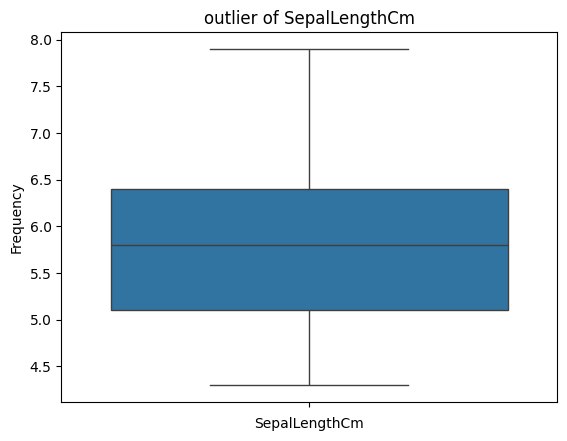

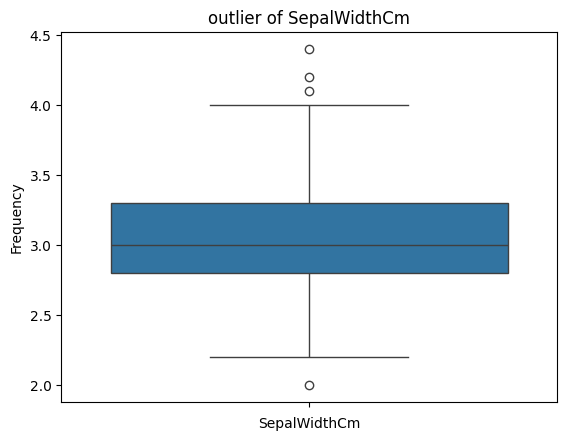

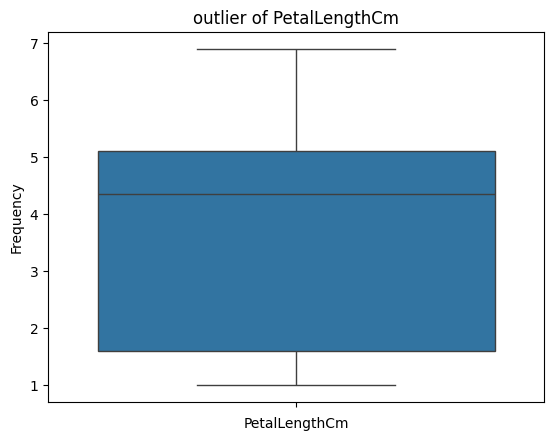

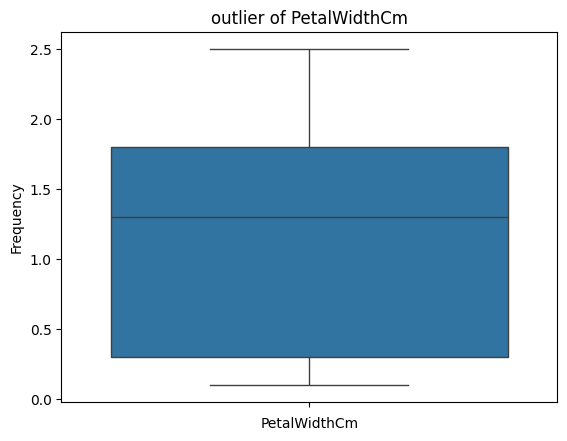

In [ ]:
num_col = data.select_dtypes(include=np.number).columns
for col in num_col:
  plt.figure()
  sns.boxplot(data[col])
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'outlier of {col}')
  plt.show()

In [ ]:
for col in num_col:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

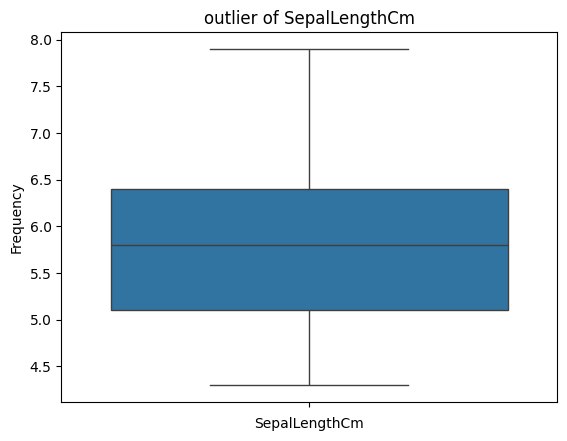

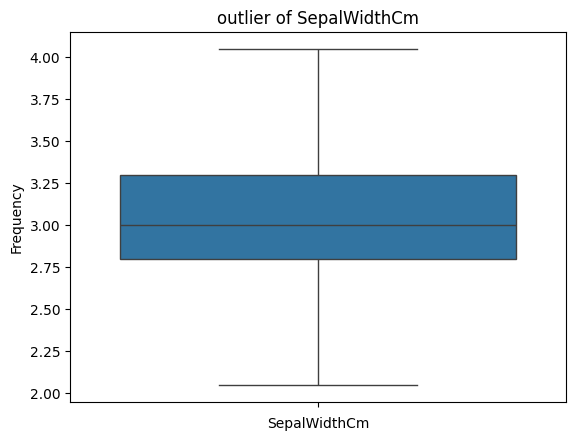

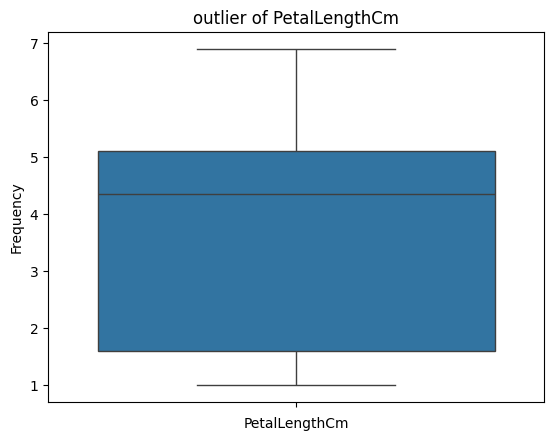

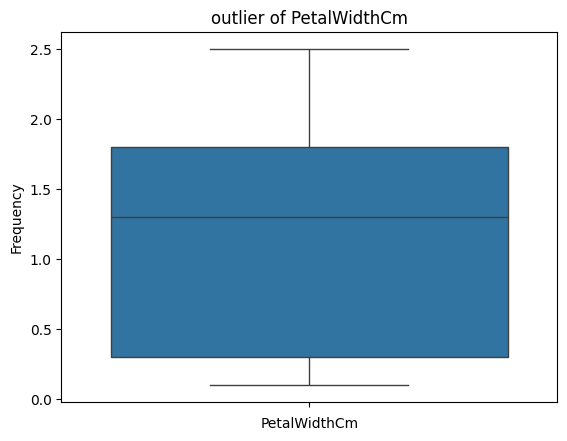

In [ ]:
for col in num_col:
  plt.figure()
  sns.boxplot(data[col])
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title(f'outlier of {col}')
  plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [ ]:
hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

In [ ]:
y_hc =hc.fit_predict(X_scaled)

In [ ]:
pca = PCA()
x_pca = pca.fit_transform(X_scaled)

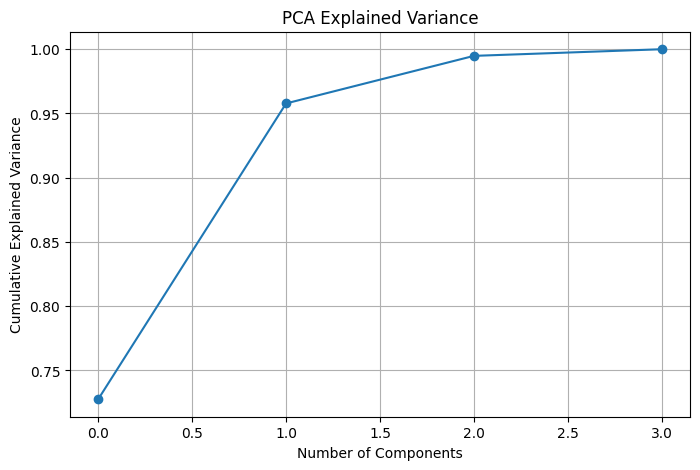

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

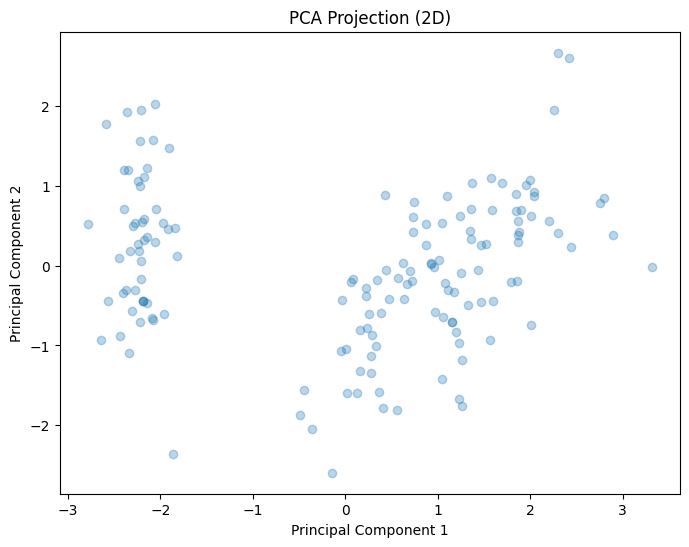

In [ ]:
pca_2 = PCA(n_components=2)

x_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(x_pca_2[:,0], x_pca_2[:,1], alpha=0.3)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection (2D)")

plt.show()

In [ ]:
score_pca = silhouette_score(x_pca_2, y_hc)

print("Silhouette Score (PCA):", score_pca)

Silhouette Score (PCA): 0.607950394189943
